# Traditional ML Stack (Raw)

Standalone notebook for the tabular workflow: universe/data build, labels, RAW dataset, RF models, AE familiarity, and combined BUY/SHORT scoring.


In [1]:
# ============================================================
# 0) Environment + Universe + Context
# ============================================================
import os
from dotenv import load_dotenv

import numpy as np
import pandas as pd

from modules.data.universe_fmp import build_large_liquid_universe_single_call
from modules.data.context import DataContext

load_dotenv()
FMP_API_KEY = os.getenv("FMP_API_KEY")
if not FMP_API_KEY:
    raise RuntimeError("Missing FMP_API_KEY in environment/.env")

# Screener universe, then keep first 7 for fast iteration
universe_full = build_large_liquid_universe_single_call(
    api_key=FMP_API_KEY,
    marketCapMoreThan=10_000_000_000,
    priceMoreThan=5,
    country="US",
    exchange="NASDAQ,NYSE,AMEX",
    isEtf=False,
    isFund=False,
    includeAllShareClasses=False,
    limit=10000,
)



universe = tuple(universe_full)
#universe = tuple(universe_full[:7])

DATA_DIR = "./data"
ctx = DataContext.from_data_dir(
    api_key=FMP_API_KEY,
    data_dir=DATA_DIR,
    db_name="quant.db",
    sleep_s=0.0,
    history_years=100,
)

print("Universe size:", len(universe))
print("Universe:", universe)


Universe size: 785
Universe: ('A', 'AA', 'AAPL', 'ABBV', 'ABC', 'ABMD', 'ABNB', 'ABT', 'ACM', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEIS', 'AEP', 'AES', 'AESC', 'AFG', 'AFL', 'AFRM', 'AGCO', 'AGNC', 'AGR', 'AIG', 'AIT', 'AIZ', 'AJG', 'AKAM', 'ALAB', 'ALB', 'ALGN', 'ALL', 'ALLY', 'ALNY', 'AM', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMH', 'AMKR', 'AMP', 'AMT', 'AMZN', 'ANET', 'ANSS', 'ANTM', 'AOS', 'APA', 'APC', 'APD', 'APG', 'APH', 'APO', 'APOS', 'APP', 'AQNB', 'AR', 'ARCC', 'ARES', 'ARMK', 'ASTS', 'ATI', 'ATO', 'ATVI', 'AVAV', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'AZPN', 'BA', 'BAC', 'BALL', 'BAX', 'BBIO', 'BBY', 'BDX', 'BDXB', 'BE', 'BEN', 'BF-B', 'BG', 'BGNE', 'BIIB', 'BIPI', 'BJ', 'BK', 'BKDT', 'BKI', 'BKNG', 'BKR', 'BLD', 'BLDR', 'BLK', 'BLL', 'BMRN', 'BMY', 'BNH', 'BNJ', 'BR', 'BRK-A', 'BRK-B', 'BRO', 'BSX', 'BURL', 'BWA', 'BWXT', 'BX', 'C', 'CACI', 'CAH', 'CARR', 'CASY', 'CAT', 'CBRE', 'CCI', 'CCIV', 'CCK', 'CCL', 'CCZ', 'CDAY', 'CDE', 'CDNS', 'CDW', 'CEG', 'CELH', '

In [2]:
# ============================================================
# 1) Build Technical / Fundamental / Macro Layers
# ============================================================
import pandas as pd
from modules.api import (
    build_technical_dataframe,
    build_fundamental_dataframe,
    build_macro_dataframe,
    _summarize_dataset_for_llm,
    summarize_technical_features,
)
from modules.features.macro_fmp import MacroFeatureConfig

start_date = "1980-01-01"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")

# -----------------------------
# Technical
# -----------------------------
technical_df, technical_cols = build_technical_dataframe(
    ctx=ctx,
    symbols=list(universe),
    start_date=start_date,
    end_date=end_date,
    verbose_data=True,
)

# Dedicated technical-only diagnostics
summarize_technical_features(technical_df, technical_cols)

# -----------------------------
# Fundamentals
# -----------------------------
fund_df, fund_cols = build_fundamental_dataframe(
    ctx=ctx,
    symbols=list(universe),
    start_date=start_date,
    end_date=end_date,
    period="quarter",
    target_index=technical_df.index,
    daily_prices=technical_df,
    verbose=True,
)

# -----------------------------
# Macro
# -----------------------------
macro_cfg = MacroFeatureConfig(
    economic_series=("CPI", "UNEMPLOYMENT", "GDP", "INFLATION", "FEDERAL_FUNDS_RATE"),
    include_treasury_rates=True,
    fill_method="ffill",
)
macro_df, macro_cols = build_macro_dataframe(
    ctx=ctx,
    start_date=start_date,
    end_date=end_date,
    config=macro_cfg,
    target_index=technical_df.index,
    verbose=True,
)

# -----------------------------
# Merge layers
# -----------------------------
final_df = pd.concat([technical_df, fund_df, macro_df], axis=1)
all_features = sorted(set(technical_cols + fund_cols + macro_cols))

# Drop all-NaN numeric features
all_nan_numeric = [
    c for c in all_features
    if c in final_df.columns
    and pd.api.types.is_numeric_dtype(final_df[c])
    and final_df[c].isna().all()
]
if all_nan_numeric:
    final_df = final_df.drop(columns=all_nan_numeric)
    all_features = [c for c in all_features if c not in all_nan_numeric]

# Final combined diagnostics
_summarize_dataset_for_llm(final_df, all_features)
print("Final shape:", final_df.shape)
print("Total active features:", len(all_features))

[A] skip FMP check (sqlite max 2026-02-18 >= latest_possible 2026-02-18)
[A] coverage: rows=6,601 start=1999-11-18 end=2026-02-18
[AA] skip FMP check (sqlite max 2026-02-18 >= latest_possible 2026-02-18)
[AA] coverage: rows=7,552 start=1996-02-13 end=2026-02-18
[AAPL] skip FMP check (sqlite max 2026-02-18 >= latest_possible 2026-02-18)
[AAPL] coverage: rows=7,552 start=1996-02-13 end=2026-02-18
[ABBV] skip FMP check (sqlite max 2026-02-18 >= latest_possible 2026-02-18)
[ABBV] coverage: rows=3,317 start=2012-12-10 end=2026-02-18
[ABC] checking FMP for new rows after 2023-09-25...
[ABC] up to date (no new rows)
[ABC] coverage: rows=6,946 start=1996-02-21 end=2023-09-25
[ABMD] checking FMP for new rows after 2022-12-23...
[ABMD] up to date (no new rows)
[ABMD] coverage: rows=6,753 start=1996-02-13 end=2022-12-23
[ABNB] skip FMP check (sqlite max 2026-02-18 >= latest_possible 2026-02-18)
[ABNB] coverage: rows=1,302 start=2020-12-10 end=2026-02-18
[ABT] skip FMP check (sqlite max 2026-02-18

/Users/johnnylee/PycharmProjects/optimal_trader/modules/features/fundamentals_fmp.py:105: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fund_df = pd.concat(dfs_per_symbol, ignore_index=True)


[fundamentals] Broadcasting to daily frequency (smearing forward)...
[fundamentals] Recomputed daily price-linked features (20): DebtToMarketCap, DividendYield, DividendYieldPercentage, EVToEBITDA, EVToFreeCashFlow, EVToOperatingCashFlow, EVToSales, EarningsYield, EnterpriseValue, EnterpriseValueMultiple, ForwardPriceToEarningsGrowthRatio, FreeCashFlowYield, MarketCap, PriceToBookRatio, PriceToEarningsGrowthRatio, PriceToEarningsRatio, PriceToFairValue, PriceToFreeCashFlowRatio, PriceToOperatingCashFlowRatio, PriceToSalesRatio

  LLM DATA DEBUG REPORT  
SHAPE:       4,033,567 rows x 107 cols
ENTITIES:    760 symbols
TIME RANGE:  1997-05-12 to 2026-02-18
SOURCE RANGE (PRE-BROADCAST): 1985-10-15 to 2026-03-18
EARLIEST USABLE NUMERIC DATE: 1997-05-12

[MISSING DATA] 101 cols have NaNs.
Top 5 worst offenders:
  - GrahamNumber                   : 16.7% missing
  - Dayssincelastfundamentalupdate : 2.1% missing
  - PriceToSalesRatio              : 1.5% missing
  - PriceToFreeCashFlowRatio    

In [3]:
# ============================================================
# 2) Build Label Frame
# ============================================================
from modules.api import build_label_dataframe

K_PARAMS = {"YE": [1, 2, 4, 8]}
EXECUTION_PARAMS = {"price_col": "close", "fee_bps": 5.0, "slippage_bps": 5.0}
WEIGHTING_PARAMS = {
    "use_sample_weight": True,
    "alpha": 4.0,
    "r_clip": 0.10,
    "horizon_balance": True,
}

symbols_in_df = set(technical_df.index.get_level_values("symbol"))
daily_map = {s: technical_df.xs(s, level="symbol") for s in universe if s in symbols_in_df}

label_df = build_label_dataframe(
    daily_by_symbol=daily_map,
    k_params=K_PARAMS,
    execution_params=EXECUTION_PARAMS,
    weighting=WEIGHTING_PARAMS,
    add_rank_labels=True,
    verbose=True,
)

print("Label rows:", len(label_df))
print("Label cols:", list(label_df.columns))


  ORACLE LABEL PERFORMANCE & DEDUPLICATION SUMMARY
DEDUPLICATION METRICS:
  - Raw Signal Count:    980,402
  - Unique Signal Count: 514,526
  - Redundancy Removed:  47.5%
--------------------------------------------------------------------------------
Horizon  Side  Trades  Mean Return %  Win Rate %  Avg Duration
  YE_k1 SHORT    8450          29.22       100.0         141.8
  YE_k1   BUY   11158          64.74       100.0         221.2
  YE_k2 SHORT   12580          20.58       100.0          71.6
  YE_k2   BUY   13198          37.55       100.0         107.5
  YE_k4 SHORT   27112          13.71       100.0          35.0
  YE_k4   BUY   26668          22.33       100.0          50.0
  YE_k8 SHORT   79604           8.66       100.0          16.3
  YE_k8   BUY   78491          12.21       100.0          21.2

Label rows: 514526
Label cols: ['target', 'side', 'horizon', 'trade_return', 'sample_weight', 'label', 'market_position', 'trade_duration_days', 'rank_y', 'side_profit']


In [4]:
# ============================================================
# 3) Build RAW Feature Frame
# ============================================================
print("--- Building RAW Feature Frame ---")

final_df_raw = final_df.copy()
print(f"RAW shape: {final_df_raw.shape}")


--- Building RAW Feature Frame ---
RAW shape: (4033567, 202)


In [5]:
# ============================================================
# 4) Build ML dataset
# ============================================================
from modules.data.preparation import MLDatasetConfig, prepare_ml_dataset

TARGETS = ["label", "rank_y", "market_position"]
WEIGHT = "sample_weight"

raw_train_data, raw_feature_list, raw_target_list = prepare_ml_dataset(
    features_df=final_df_raw,
    labels_df=label_df,
    target_cols=TARGETS,
    weight_col=WEIGHT,
    config=MLDatasetConfig(drop_nan_features=False),
    verbose=True,
)

print("RAW train rows:", len(raw_train_data), "features:", len(raw_feature_list))


--- Preparing ML Training Dataset ---
  - Final Training Rows: 514,526
  - Active Features:     202
  - Targets:             ['label', 'rank_y', 'market_position']
  - Sample Weight Col:   sample_weight
RAW train rows: 514526 features: 202


In [6]:
# ============================================================
# 5) Train Classifier + Regressor
# ============================================================
from modules.workflows import train_rf_models

print("--- Training RAW RF models ---")
clf_raw, reg_raw = train_rf_models(raw_train_data, raw_feature_list)

--- Training RAW RF models ---

  DIAGNOSTIC: SKLEARN RANDOM FOREST CLASSIFIER (TEST RESULTS)
DATASET & SPLIT:
  - Total Observations: 514,526
  - Random Split:       80.0% Train / 20.0% Test
  - Features:           198 numeric (filtered 5 strings)

CLASS DISTRIBUTION (Mapping: {0: 'buy', 1: 'short', 2: 'sell', 3: 'cover'}):
               Train Set              Test Set
  -      buy: 103,598 (25.2%)    25,900 (25.2%)
  -    short: 102,210 (24.8%)    25,553 (24.8%)
  -     sell: 103,626 (25.2%)    25,907 (25.2%)
  -    cover: 102,186 (24.8%)    25,546 (24.8%)

TEST PERFORMANCE:
  - Accuracy:           98.31%

CONFUSION MATRIX (Test Set):
            Pred     buy Pred   short Pred    sell Pred   cover 
True     buy:        25179          721            0            0 
True   short:          612        24941            0            0 
True    sell:           63          165        25679            0 
True   cover:          135           44            0        25367 

TOP 10 FEATURES:
  -

In [7]:
# ============================================================
# 6) Train Autoencoder (numeric-only) + Save Artifacts
# ============================================================
from modules.workflows import train_ae, save_raw_stack_artifacts

print("--- Training RAW AE ---")
ae_raw, ae_raw_numeric_cols = train_ae(raw_train_data, raw_feature_list)

artifact_dir = save_raw_stack_artifacts(
    clf_raw=clf_raw,
    reg_raw=reg_raw,
    ae_raw=ae_raw,
    raw_feature_list=raw_feature_list,
    ae_raw_numeric_cols=ae_raw_numeric_cols,
    artifact_dir="./artifacts/raw_stack",
    flavor_space=None,
)
print(f"Saved training artifacts to: {artifact_dir.resolve()}")


--- Training RAW AE ---

  DIAGNOSTIC: AUTOENCODER REPORT
### 1. MODEL STATE
- Type: NUMERIC_ONLY
- Numeric inputs: 197
- Categorical inputs: 0
- Encoder layers: 3
- Bottleneck dim: 24
- MSE (Mean): 2.042203
- MSE (P95):  8.478299

### 2. TOP FEATURE RECONSTRUCTION MSE (TRAIN, STANDARDIZED)
- EBTPerEBIT: 10.175969
- InterestBurden: 9.015815
- IncomeQuality: 8.984880
- FixedAssetTurnover: 8.194896
- DividendPayoutRatio: 7.670364
- SMASlope200: 7.031178
- SMASlope100: 6.575155
- PayablesTurnover: 6.356777
- NetDebtToEBITDA: 5.960965
- StockBasedCompensationToRevenue: 5.555662
Saved training artifacts to: /Users/johnnylee/PycharmProjects/optimal_trader/artifacts/raw_stack


In [8]:
import pandas as pd
pd.set_option("display.max_colwidth", None)

# ============================================================
# 8) Cluster "alpha flavors" + packets (safer config)
# ============================================================
from modules.analysis.alpha_flavors import (
    AlphaFlavorClusterConfig,
    fit_flavor_space,
)

# Raw-only stack
ae_model = ae_raw
source_df = raw_train_data
ae_numeric = ae_raw_numeric_cols
flavor_space_var = "alpha_flavor_space_raw"

df = source_df.copy()

print(
    f"Rows={len(df):,} | Symbols="
    f"{df.index.get_level_values('symbol').nunique() if isinstance(df.index, pd.MultiIndex) and 'symbol' in df.index.names else 'N/A'}"
)

# Force refit if you changed settings
cached = globals().get(flavor_space_var)
need_refit = True
if cached is not None:
    try:
        need_refit = not cached.clustered_df.index.equals(df.index)
    except Exception:
        need_refit = True

if need_refit:
    print("[FLAVOR SPACE] fitting/rebuilding...")
    flavor_space = fit_flavor_space(
        df=df,
        ae_model=ae_model,
        numeric_cols=list(ae_numeric),
        categorical_cols=[],
        cfg=AlphaFlavorClusterConfig(
            cluster_col="cluster_id",
            ret_col="trade_return",
            cluster_algo="hdbscan",
            auto_k=True,
            auto_k_method="elbow",
            k_min=10,
            k_max=30,
            k_step=5,

            # reduce memory/time pressure
            fit_sample_size=0.02,          # was 0.10
            hdbscan_min_cluster_size=200,  # was 100
            hdbscan_min_samples=None,

            include_ae_breaks=False,
            distance_temperature=1.0,

            # IMPORTANT:
            # euclidean here is stable/scalable.
            # (If latents are roughly normalized, this behaves close to cosine neighborhood-wise.)
            distance_metric="euclidean",
        ),
        verbose=True,
    )
    globals()[flavor_space_var] = flavor_space
else:
    print("[FLAVOR SPACE] reusing cached space (same index).")
    flavor_space = cached

cluster_summary_df = flavor_space.summary_df.copy()
packets = flavor_space.packets

print("Cluster summary (all clusters):")
display(cluster_summary_df)

Rows=514,526 | Symbols=760
[FLAVOR SPACE] fitting/rebuilding...
[CLUSTER SANITY] X shape=(514526, 24) absmax=42.4060 q99abs=9.2313 finite=1.000000
[CLUSTER] Finalizing with HDBSCAN (min_cluster_size=200, min_samples=None)...

[CLUSTER] HDBSCAN returned all noise; falling back to KMeans.
[PACKETS] clusters=10 rows=1,835,060 has_returns=True

Cluster summary (all clusters):


,cluster,rows,cluster_pct,mean_return,sharpe,std_return,p10,p90,mean_duration,std_duration,top_feature_tuples,dominant_symbol_mode,symbol_concentration,dominant_year_month_mode,time_concentration
0,9,1106716,60.309527,0.153016,0.700866,0.218324,0.033962,0.322199,41.828793,57.181947,"[(ShortTermOperatingCashFlowCoverageRatio, -1.70σ), (CashPerShare, -1.48σ), (NetCurrentAssetValue, +1.19σ), (DebtServiceCoverageRatio, -1.19σ), (WorkingCapital, +0.99σ), (AveragePayables, -0.96σ), (StockBasedCompensationToRevenue, -0.93σ), (ResearchAndDevelopementToRevenue, -0.91σ), (AverageReceivables, -0.85σ), (OperatingCashFlowCoverageRatio, -0.78σ), (GrahamNetNet, +0.75σ), (DaysOfPayablesOutstanding, -0.74σ), (OBV, -0.73σ), (ReceivablesTurnover, -0.73σ), (EnterpriseValue, -0.72σ), (MarketCap, -0.68σ), (QuickRatio, -0.68σ), (DollarVol, -0.67σ), (FreeCashFlowToEquity, +0.64σ), (Volume, -0.62σ), (TrueRange, -0.62σ), (PriceToSalesRatio, -0.58σ), (TangibleAssetValue, -0.56σ), (InterestCoverageRatio, -0.56σ), (CurrentRatio, -0.56σ)]","MMM (3241 rows, 0.3%)",HHI=0.0020 effective_symbols≈491.85,"2011-08 (5981 rows, 0.5%)",HHI=0.0031 effective_months≈324.52
1,2,221576,12.074592,0.173692,0.660624,0.262922,0.037073,0.360038,42.674550,58.756975,"[(ShortTermOperatingCashFlowCoverageRatio, +8.50σ), (WorkingCapital, +3.64σ), (OBV, +2.50σ), (OperatingCashFlowCoverageRatio, +1.99σ), (Volume, +1.65σ), (PriceToFreeCashFlowRatio, +1.46σ), (DebtServiceCoverageRatio, +1.46σ), (DividendPaidAndCapexCoverageRatio, +1.45σ), (InterestCoverageRatio, +1.42σ), (DollarVol, +1.39σ), (EVToFreeCashFlow, +1.32σ), (TrueRange, +1.32σ), (NetCurrentAssetValue, +1.32σ), (CapitalExpenditureCoverageRatio, +1.20σ), (MarketCap, +1.12σ), (High, +1.07σ), (Close, +1.07σ), (Open, +1.07σ), (Low, +1.07σ), (PriceToEarningsRatio, +1.07σ), (WorkingCapitalTurnoverRatio, +1.04σ), (BottomLineProfitMargin, +1.03σ), (ContinuousOperationsProfitMargin, +1.01σ), (NetProfitMargin, +1.01σ), (PriceToFairValue, +1.00σ)]","CSCO (2807 rows, 1.3%)",HHI=0.0034 effective_symbols≈294.90,"2020-03 (2475 rows, 1.1%)",HHI=0.0044 effective_months≈227.86
2,7,146808,8.000174,0.141176,0.440705,0.320341,0.032103,0.294743,42.130415,57.166814,"[(WorkingCapital, -9.39σ), (CashPerShare, +4.87σ), (NetCurrentAssetValue, -4.03σ), (AveragePayables, +3.58σ), (FreeCashFlowToFirm, +3.18σ), (AverageReceivables, +2.98σ), (GrahamNetNet, -2.85σ), (DaysOfPayablesOutstanding, +2.37σ), (FreeCashFlowToEquity, -2.06σ), (ShortTermOperatingCashFlowCoverageRatio, -2.01σ), (CashConversionCycle, -1.81σ), (FinancialLeverageRatio, +1.69σ), (ReturnOnInvestedCapital, +1.62σ), (DebtServiceCoverageRatio, -1.55σ), (CapitalExpenditureCoverageRatio, +1.45σ), (ResearchAndDevelopementToRevenue, -1.44σ), (QuickRatio, -1.36σ), (DaysOfSalesOutstanding, +1.32σ), (CurrentRatio, -1.32σ), (ReceivablesTurnover, -1.28σ), (WorkingCapitalTurnoverRatio, +1.19σ), (DebtToMarketCap, +1.18σ), (PriceToBookRatio, -1.08σ), (PriceToFairValue, -1.08σ), (FreeCashFlowYield, +1.07σ)]","CMA (3335 rows, 2.3%)",HHI=0.0095 effective_symbols≈104.77,"2020-04 (1371 rows, 0.9%)",HHI=0.0036 effective_months≈275.12
3,3,94093,5.127516,0.244511,0.542912,0.450370,0.044021,0.488630,41.563187,56.599143,"[(QuickRatio, +7.99σ), (ResearchAndDevelopementToRevenue, +7.24σ), (CurrentRatio, +7.10σ), (StockBasedCompensationToRevenue, +6.15σ), (PriceToBookRatio, +5.83σ), (PriceToFairValue, +5.83σ), (CashRatio, +5.05σ), (WorkingCapital, +4.04σ), (EVToOperatingCashFlow, -3.72σ), (PriceToOperatingCashFlowRatio, -3.67σ), (NetIncomePerEBT, +3.38σ), (TaxBurden, +3.38σ), (EVToEBITDA, -3.02σ), (EnterpriseValueMultiple, -3.02σ), (FreeCashFlowOperatingCashFlowRatio, +3.02σ), (CapexToOperatingCashFlow, -3.00σ), (EffectiveTaxRate, -2.64σ), (PriceToSalesRatio, +2.53σ), (DebtServiceCoverageRatio, -2.25σ), (InterestCoverageRatio, -2.21σ), (ReturnOnEquity, -2.13σ), (ForwardPriceToEarningsGrowthRatio, -2.08σ), (PriceToEarningsGrowthRatio, -2.08σ), (ContinuousOperationsProfitMargin, -2.01σ), (BottomLineProfitMargin, -2.00σ

/Users/johnnylee/miniconda3/envs/optimal_trader/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/johnnylee/miniconda3/envs/optimal_trader/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/johnnylee/miniconda3/envs/optimal_trader/lib/python3.13/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/johnnylee/miniconda3/envs/optimal_trader/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/johnnylee/miniconda3/envs/optimal_trader/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/johnnylee/miniconda3/envs/optimal_trader/lib/python3.13

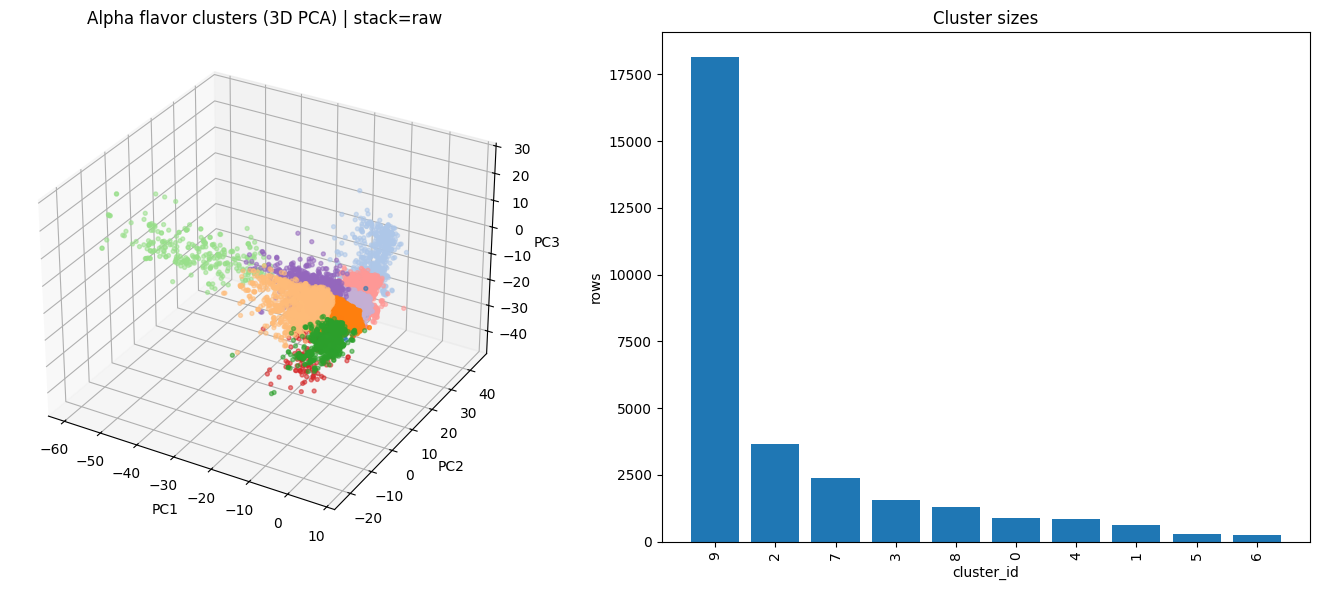

Explained variance: PC1=0.297, PC2=0.214, PC3=0.124, Total=0.634
Legend preview (first 10 clusters): ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9']


In [9]:
# -----------------------------
# Cluster visualization (3D PCA)
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

plot_df = flavor_space.clustered_df.copy()
cluster_col = str(flavor_space.cluster_col)
latent_cols = list(flavor_space.latent_cols)

if cluster_col not in plot_df.columns:
    raise KeyError(f"Missing cluster column '{cluster_col}' in flavor_space.clustered_df")

MAX_PLOT_POINTS = 30000
if len(plot_df) > MAX_PLOT_POINTS:
    plot_df = plot_df.sample(MAX_PLOT_POINTS, random_state=1337)

plot_df = plot_df.dropna(subset=[cluster_col]).copy()
clusters = pd.to_numeric(plot_df[cluster_col], errors="coerce").fillna(-1).astype(int)
plot_df = plot_df.loc[clusters >= 0].copy()
clusters = clusters.loc[clusters >= 0]

available_latent = [c for c in latent_cols if c in plot_df.columns]
if len(available_latent) == len(latent_cols) and len(latent_cols) > 0:
    X_latent = plot_df[latent_cols].to_numpy(dtype=float, copy=False)
else:
    # clustered_df may not persist z_* columns; compute latent on demand.
    z = ae_model.latent(
        plot_df,
        numeric_cols=list(flavor_space.numeric_cols),
        categorical_cols=list(flavor_space.categorical_cols),
    )
    X_latent = np.asarray(z, dtype=float)

if len(plot_df) >= 3 and X_latent.ndim == 2 and X_latent.shape[1] >= 3:
    X_latent = np.nan_to_num(X_latent, nan=0.0, posinf=0.0, neginf=0.0)

    pca = PCA(n_components=3, random_state=1337)
    z3 = pca.fit_transform(X_latent)

    viz = plot_df[[cluster_col]].copy()
    viz["pc1"] = z3[:, 0]
    viz["pc2"] = z3[:, 1]
    viz["pc3"] = z3[:, 2]

    unique_clusters = sorted(viz[cluster_col].astype(int).unique())
    cmap = plt.cm.get_cmap("tab20", max(20, len(unique_clusters)))

    fig = plt.figure(figsize=(14, 6))
    ax = fig.add_subplot(121, projection="3d")

    # 3D PCA projection
    for i, c in enumerate(unique_clusters):
        g = viz[viz[cluster_col].astype(int) == int(c)]
        ax.scatter(g["pc1"], g["pc2"], g["pc3"], s=8, alpha=0.55, color=cmap(i), label=f"C{c}")
    ax.set_title("Alpha flavor clusters (3D PCA) | stack=raw")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")

    # Cluster size
    ax2 = fig.add_subplot(122)
    counts = clusters.value_counts().sort_values(ascending=False)
    ax2.bar(counts.index.astype(str), counts.values)
    ax2.set_title("Cluster sizes")
    ax2.set_xlabel(cluster_col)
    ax2.set_ylabel("rows")
    ax2.tick_params(axis="x", labelrotation=90)

    plt.tight_layout()
    plt.show()

    evr = pca.explained_variance_ratio_
    print(
        f"Explained variance: PC1={evr[0]:.3f}, PC2={evr[1]:.3f}, PC3={evr[2]:.3f}, "
        f"Total={evr[:3].sum():.3f}"
    )
    topn = min(12, len(unique_clusters))
    print(f"Legend preview (first {topn} clusters):", [f"C{c}" for c in unique_clusters[:topn]])
else:
    print("Not enough valid rows/latent dimensions for 3D PCA cluster visualization.")


In [10]:
# ============================================================
# 7) Latest-date scoring (cluster familiarity)
# ============================================================
from modules.engine.latest import score_latest_with_cluster_familiarity
from modules.analysis import add_cluster_explanations

train_df = raw_train_data
clf = clf_raw
reg = reg_raw
ae_model_for_scoring = ae_raw
flavor_space = globals().get("alpha_flavor_space_raw")

if flavor_space is None:
    raise RuntimeError("Flavor space is missing. Run the alpha flavor fit cell first.")

latest_date, scored = score_latest_with_cluster_familiarity(
    train_data=train_df,
    clf=clf,
    reg=reg,
    ae_model=ae_model_for_scoring,
    flavor_space=flavor_space,
    market_position_value=0,
    round_decimals=None,
)

scored = add_cluster_explanations(
    scored,
    flavor_space=flavor_space,
    top_matches=5,
    top_deviations=3,
)

# Average-based scoring (instead of multiply)
scored["buy_score"] = (
    pd.to_numeric(scored["clf__prob_buy"], errors="coerce").fillna(0.0)
    + pd.to_numeric(scored["ranking"], errors="coerce").fillna(0.0)
    + pd.to_numeric(scored["cluster_familiarity"], errors="coerce").fillna(0.0)
) / 3.0

scored["short_score"] = (
    pd.to_numeric(scored["clf__prob_short"], errors="coerce").fillna(0.0)
    + pd.to_numeric(scored["ranking"], errors="coerce").fillna(0.0)
    + pd.to_numeric(scored["cluster_familiarity"], errors="coerce").fillna(0.0)
) / 3.0

cluster_col = str(flavor_space.cluster_col)
min_dist_col = f"{cluster_col}__min_dist"
show_cols = [
    "clf__prob_buy",
    "clf__prob_short",
    "ranking",
    cluster_col,
    min_dist_col,
    "cluster_familiarity",
    "top_matching_features",
    "top_deviating_features",
    "cluster_mean_return",
    "cluster_sharpe",
    "cluster_mean_duration",
    "buy_score",
    "short_score",
]
show_cols = [c for c in show_cols if c in scored.columns]

TOP_N_DISPLAY = 20
TOP_N_LIST = 30
PRINT_SYMBOL_LISTS = False

base_eligible = scored.loc[
    (pd.to_numeric(scored["ranking"], errors="coerce") > 0.5)
    & (pd.to_numeric(scored["cluster_familiarity"], errors="coerce") > 0.5)
].copy()

buy_pool = base_eligible.loc[pd.to_numeric(base_eligible["clf__prob_buy"], errors="coerce") > 0.5].copy()
short_pool = base_eligible.loc[pd.to_numeric(base_eligible["clf__prob_short"], errors="coerce") > 0.5].copy()

buy_top = buy_pool.nlargest(TOP_N_DISPLAY, "buy_score")[show_cols]
short_top = short_pool.nlargest(TOP_N_DISPLAY, "short_score")[show_cols]
buy_list = buy_pool.nlargest(TOP_N_LIST, "buy_score").index.tolist()
short_list = short_pool.nlargest(TOP_N_LIST, "short_score").index.tolist()

print(
    f"stack=raw | date={latest_date.date()} | rows={len(scored):,} "
    f"| base_eligible={len(base_eligible):,} | buy_pool={len(buy_pool):,} | short_pool={len(short_pool):,}"
)
display(buy_top)
display(short_top)

if PRINT_SYMBOL_LISTS:
    print(f"BUY symbols (top {TOP_N_LIST}):")
    print(buy_list)
    print(f"SHORT symbols (top {TOP_N_LIST}):")
    print(short_list)


stack=raw | date=2026-02-18 | rows=248 | base_eligible=68 | buy_pool=11 | short_pool=55


,clf__prob_buy,clf__prob_short,ranking,cluster_id,cluster_id__min_dist,cluster_familiarity,top_matching_features,top_deviating_features,cluster_mean_return,cluster_sharpe,cluster_mean_duration,buy_score,short_score
symbol,,,,,,,,,,,,,
PANW,0.888061,0.005955,0.715168,2,4.056889,0.940508,"[(CapitalExpenditureCoverageRatio, -0.00σ), (PriceToFairValue, -0.00σ), (BottomLineProfitMargin, +0.01σ), (NetProfitMargin, +0.01σ), (ContinuousOperationsProfitMargin, +0.01σ)]","[(DollarVol, +3.36σ vs cluster), (MarketCap, +0.42σ vs cluster), (Volume, +0.17σ vs cluster)]",0.173692,0.660624,42.674550,0.847913,0.553877
FTNT,0.887051,0.014713,0.544402,2,3.981294,0.951908,"[(CapitalExpenditureCoverageRatio, -0.00σ), (PriceToEarningsRatio, -0.00σ), (NetProfitMargin, +0.01σ), (BottomLineProfitMargin, +0.01σ), (ContinuousOperationsProfitMargin, +0.01σ)]","[(Volume, -0.32σ vs cluster), (ShortTermOperatingCashFlowCoverageRatio, -0.16σ vs cluster), (MarketCap, +0.08σ vs cluster)]",0.173692,0.660624,42.674550,0.794454,0.503675
OKTA,0.883465,0.017274,0.624986,2,4.489530,0.856027,"[(CapitalExpenditureCoverageRatio, -0.00σ), (PriceToFairValue, -0.00σ), (BottomLineProfitMargin, +0.01σ), (NetProfitMargin, +0.01σ), (TrueRange, -0.01σ)]","[(Volume, -0.39σ vs cluster), (OBV, -0.33σ vs cluster), (MarketCap, -0.28σ vs cluster)]",0.173692,0.660624,42.674550,0.788159,0.499429
AR,0.868794,0.029065,0.550083,9,1.733496,0.873894,"[(DaysOfPayablesOutstanding, -0.00σ), (GrahamNetNet, +0.00σ), (CashPerShare, -0.00σ), (PriceToSalesRatio, -0.00σ), (StockBasedCompensationToRevenue, -0.00σ)]","[(AverageReceivables, -0.08σ vs cluster), (AveragePayables, -0.07σ vs cluster), (TangibleAssetValue, +0.06σ vs cluster)]",0.153016,0.700866,41.828793,0.764257,0.484347
ELAN,0.878295,0.034252,0.537143,8,8.145099,0.839917,"[(CapexToRevenue, -0.00σ), (IncomeQuality, -0.01σ), (OperatingCashFlowCoverageRatio, -0.00σ), (PriceToBookRatio, -0.00σ), (PriceToFairValue, -0.00σ)]","[(DebtToEquityRatio, +0.27σ vs cluster), (InterestBurden, -0.21σ vs cluster), (FreeCashFlowOperatingCashFlowRatio, +0.13σ vs cluster)]",0.261067,0.416638,42.461065,0.751785,0.470437
WDAY,0.889096,0.005371,0.772862,2,5.571470,0.580257,"[(PriceToFairValue, -0.00σ), (PriceToEarningsRatio, -0.00σ), (CapitalExpenditureCoverageRatio, -0.00σ), (BottomLineProfitMargin, +0.01σ), (NetProfitMargin, +0.01σ)]","[(OBV, -0.34σ vs cluster), (Volume, -0.33σ vs cluster), (DollarVol, +0.28σ vs cluster)]",0.173692,0.660624,42.674550,0.747405,0.452830
GPC,0.889582,0.008174,0.692981,8,9.554764,0.595510,"[(CapexToRevenue, -0.00σ), (IncomeQuality, -0.01σ), (OperatingCashFlowCoverageRatio, -0.00σ), (PriceToBookRatio, -0.00σ), (PriceToFairValue, -0.00σ)]","[(DebtToEquityRatio, +0.31σ vs cluster), (InterestBurden, -0.14σ vs cluster), (FreeCashFlowOperatingCashFlowRatio, +0.13σ vs cluster)]",0.261067,0.416638,42.461065,0.726024,0.432222
VMC,0.888362,0.016160,0.526040,2,5.316118,0.645372,"[(PriceToEarningsRatio, -0.00σ), (PriceToFairValue, -0.00σ), (CapitalExpenditureCoverageRatio, -0.00σ), (BottomLineProfitMargin, +0.01σ), (NetProfitMargin, +0.01σ)]","[(ShortTermOperatingCashFlowCoverageRatio, +2.16σ vs cluster), (Volume, -0.42σ vs cluster), (OBV, -0.35σ vs cluster)]",0.173692,0.660624,42.674550,0.686592,0.395858
GIS,0.880314,0.008017,0.515289,9,2.128655,0.630026,"[(DaysOfPayablesOutstanding, -0.00σ), (GrahamNetNet, +0.00σ), (CashPerShare, -0.00σ), (PriceToSalesRatio, -0.00σ), (StockBasedCompensationToRevenue, -0.00σ)]","[(DollarVol, +0.28σ vs cluster), (FreeCashFlowToEquity, -0.22σ vs cluster), (AveragePayables, +0.22σ vs cluster)]",0.153016,0.700866,41.828793,0.675210,0.384444


,clf__prob_buy,clf__prob_short,ranking,cluster_id,cluster_id__min_dist,cluster_familiarity,top_matching_features,top_deviating_features,cluster_mean_return,cluster_sharpe,cluster_mean_duration,buy_score,short_score
symbol,,,,,,,,,,,,,
RVMD,0.048005,0.810792,0.605707,3,6.094334,0.977660,"[(ForwardPriceToEarningsGrowthRatio, -0.00σ), (PriceToEarningsGrowthRatio, -0.00σ), (ContinuousOperationsProfitMargin, +0.01σ), (BottomLineProfitMargin, +0.01σ), (StockBasedCompensationToRevenue, -0.00σ)]","[(CashRatio, -0.14σ vs cluster), (WorkingCapital, -0.13σ vs cluster), (QuickRatio, -0.12σ vs cluster)]",0.244511,0.542912,41.563187,0.543791,0.798053
MRNA,0.040466,0.807776,0.734698,3,7.516044,0.843230,"[(ForwardPriceToEarningsGrowthRatio, -0.00σ), (PriceToEarningsGrowthRatio, -0.00σ), (StockBasedCompensationToRevenue, -0.00σ), (DebtServiceCoverageRatio, -0.01σ), (CapexToOperatingCashFlow, -0.01σ)]","[(CashRatio, -0.14σ vs cluster), (QuickRatio, -0.13σ vs cluster), (CurrentRatio, -0.13σ vs cluster)]",0.244511,0.542912,41.563187,0.539465,0.795234
DECK,0.046262,0.774825,0.652797,4,5.174832,0.951861,"[(InterestDebtPerShare, -0.00σ), (GrahamNetNet, +0.00σ), (CashPerShare, -0.00σ), (ReceivablesTurnover, +0.00σ), (ContinuousOperationsProfitMargin, +0.01σ)]","[(OperatingReturnOnAssets, +0.80σ vs cluster), (ShortTermOperatingCashFlowCoverageRatio, -0.53σ vs cluster), (Volume, -0.42σ vs cluster)]",0.176569,0.729594,41.897187,0.550307,0.793161
APH,0.016628,0.824422,0.585789,2,4.003931,0.948392,"[(PriceToEarningsRatio, -0.00σ), (NetProfitMargin, +0.01σ), (BottomLineProfitMargin, +0.01σ), (CapitalExpenditureCoverageRatio, -0.00σ), (ContinuousOperationsProfitMargin, +0.01σ)]","[(MarketCap, +1.03σ vs cluster), (DollarVol, +0.60σ vs cluster), (Volume, -0.28σ vs cluster)]",0.173692,0.660624,42.674550,0.516936,0.786201
NEM,0.036856,0.785793,0.611458,2,4.027146,0.945274,"[(PriceToFairValue, -0.00σ), (CapitalExpenditureCoverageRatio, -0.00σ), (High, -0.03σ), (Open, -0.03σ), (Low, -0.03σ)]","[(MarketCap, +0.68σ vs cluster), (DollarVol, +0.49σ vs cluster), (OBV, -0.31σ vs cluster)]",0.173692,0.660624,42.674550,0.531196,0.780842
NTRA,0.089933,0.772590,0.585034,3,6.059412,0.979000,"[(ForwardPriceToEarningsGrowthRatio, -0.00σ), (PriceToEarningsGrowthRatio, -0.00σ), (StockBasedCompensationToRevenue, -0.00σ), (BottomLineProfitMargin, +0.01σ), (ContinuousOperationsProfitMargin, +0.01σ)]","[(WorkingCapital, -0.13σ vs cluster), (QuickRatio, -0.13σ vs cluster), (CurrentRatio, -0.13σ vs cluster)]",0.244511,0.542912,41.563187,0.551322,0.778875
CDNS,0.034209,0.795196,0.590828,2,4.416469,0.873059,"[(CapitalExpenditureCoverageRatio, -0.00σ), (PriceToEarningsRatio, -0.00σ), (PriceToFairValue, -0.00σ), (NetProfitMargin, +0.01σ), (PriceToFreeCashFlowRatio, -0.00σ)]","[(DollarVol, +0.70σ vs cluster), (Volume, -0.36σ vs cluster), (OBV, -0.28σ vs cluster)]",0.173692,0.660624,42.674550,0.499365,0.753028
COIN,0.099748,0.733649,0.729799,3,8.141847,0.778889,"[(ForwardPriceToEarningsGrowthRatio, -0.00σ), (PriceToEarningsGrowthRatio, -0.00σ), (StockBasedCompensationToRevenue, -0.00σ), (ResearchAndDevelopementToRevenue, -0.01σ), (DebtServiceCoverageRatio, -0.01σ)]","[(CashRatio, -0.14σ vs cluster), (QuickRatio, -0.13σ vs cluster), (CurrentRatio, -0.13σ vs cluster)]",0.244511,0.542912,41.563187,0.536145,0.747446
TLN,0.011949,0.808088,0.655450,2,4.852581,0.778076,"[(CapitalExpenditureCoverageRatio, -0.00σ), (PriceToFairValue, -0.00σ), (PriceToEarningsRatio, -0.00σ), (NetProfitMargin, +0.01σ), (BottomLineProfitMargin, +0.01σ)]","[(Volume, -0.44σ vs cluster), (OBV, -0.36σ vs cluster), (MarketCap, -0.26σ vs cluster)]",0.173692,0.660624,42.674550,0.481825,0.747205


In [11]:
# Reusable single-symbol inference helpers (moved to modules/workflows/inference.py)
from modules.workflows import predict_symbol_fresh, pretty_print_symbol_prediction

# Example:
# latest_dt, pred = predict_symbol_fresh(
#     "AMD",
#     ctx=ctx,
#     clf_raw=clf_raw,
#     reg_raw=reg_raw,
#     ae_raw=ae_raw,
#     flavor_space=globals()["alpha_flavor_space_raw"],
# )
# pretty_print_symbol_prediction("AMD", latest_dt, pred)


In [13]:
scored[show_cols].describe()

,clf__prob_buy,clf__prob_short,ranking,cluster_id,cluster_id__min_dist,cluster_familiarity,cluster_mean_return,cluster_sharpe,cluster_mean_duration,buy_score,short_score
count,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000,248.000000
mean,0.267517,0.576748,0.562300,5.572581,6.355412,0.420052,0.170514,0.648918,42.161760,0.416623,0.519700
std,0.344263,0.318601,0.099779,3.392474,3.875916,0.277825,0.031859,0.082058,0.417425,0.150720,0.141953
min,0.008464,0.005206,0.315612,0.000000,1.688821,0.000420,0.141176,0.416638,40.799362,0.150518,0.221556
25%,0.025804,0.262595,0.502700,2.000000,3.763254,0.188413,0.153016,0.660624,41.828793,0.290577,0.421340
50%,0.056358,0.772064,0.563621,7.000000,5.506424,0.373805,0.154730,0.661005,41.897187,0.395656,0.522074
75%,0.622948,0.798164,0.627675,9.000000,7.957862,0.644854,0.173692,0.700866,42.674550,0.526283,0.618506
max,0.901054,0.841674,0.791033,9.000000,27.227930,0.998073,0.346074,0.729594,42.783438,0.847913,0.798053
